In [1]:
import numpy as np
#import torch
#import jax
#import jax.numpy as jnp
# mute this since it requires py3.8 and py3.10 env, not default py3.11
#import tensorflow as tf
import iree.compiler
import iree.runtime
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# IREE version: candidate-20230815.614

# use DCMAKE_BUILD_TYPE=RelWithDebInfo or Debug and DIREE_ENABLE_ASSERTIONS=ON

/tmp/ipykernel_2514382/937203960.py:9: DeprecationWarning: 
Pyarrow will become a required dependency of pandas in the next major release of pandas (pandas 3.0),
(to allow more performant data types, such as the Arrow string type, and better interoperability with other libraries)
but was not found to be installed on your system.
If this would cause problems for you,
please provide us feedback at https://github.com/pandas-dev/pandas/issues/54466
        
  import pandas as pd


# Input: BMM 8x512x1024x512

In [2]:
!cat ../operator-cases/matmul.mlir
!../../build/bin/ragdoll-opt \
    ../operator-cases/matmul.mlir \
    --pass-pipeline="builtin.module(func.func( \
    tosa-to-linalg-named \
))" > ../../build/.matmul.mlir.linalg
    # --pass-pipeline="builtin.module(func.func(tosa-to-linalg-named, linalg-generalize-named-ops))" > ../../build/.matmul.mlir.linalg
!cat ../../build/.matmul.mlir.linalg

module {
  func.func @matmul(%arg0: tensor<1026x2556xf32>, %arg1: tensor<2556x1026xf32>) -> tensor<1026x1026xf32> {
    %c0 = arith.constant 0.0 : f32
    %0 = tensor.empty() : tensor<1026x1026xf32>
    %1 = linalg.fill ins(%c0 : f32) outs(%0 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    %2 = linalg.matmul ins(%arg0, %arg1 : tensor<1026x2556xf32>, tensor<2556x1026xf32>) outs(%1 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    return %2 : tensor<1026x1026xf32>
  }
}
module {
  func.func @matmul(%arg0: tensor<1026x2556xf32>, %arg1: tensor<2556x1026xf32>) -> tensor<1026x1026xf32> {
    %cst = arith.constant 0.000000e+00 : f32
    %0 = tensor.empty() : tensor<1026x1026xf32>
    %1 = linalg.fill ins(%cst : f32) outs(%0 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    %2 = linalg.matmul ins(%arg0, %arg1 : tensor<1026x2556xf32>, tensor<2556x1026xf32>) outs(%1 : tensor<1026x1026xf32>) -> tensor<1026x1026xf32>
    return %2 : tensor<1026x1026xf32>
  }
}



# Baseline: Default IREE codegen solution

In [3]:
# one-off version
!nohup iree-compile ../../build/.matmul.mlir.linalg \
-o ../../build/.matmul.vmfb \
--mlir-print-ir-after-all \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_70 > ../../build/basic_dump.mlir 2>&1

# benchmark version with repeatance
!nohup iree-compile ../../build/.matmul.mlir.linalg \
-o ../../build/.matmul.vmfb.benchmark \
--mlir-print-ir-after-all \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count=17 \
--iree-hal-cuda-llvm-target-arch=sm_70 > ../../build/basic_dump.mlir 2>&1

# DIY: Configure Matmul Kernel with JIT-recipe

In [4]:
!iree-compile ../../build/.matmul.mlir.linalg \
--compile-from=input \
--compile-to=executable-sources \
--iree-hal-target-backends=cuda \
--iree-opt-const-eval=1 \
--iree-opt-const-expr-hoisting=1 \
--iree-opt-numeric-precision-reduction=1 \
--iree-hal-cuda-llvm-target-arch=sm_86 > ../../build/.matmul.mlir.executable-sources
!cat ../../build/.matmul.mlir.executable-sources

module attributes {hal.device.targets = [#hal.device.target<"cuda", {executable_targets = [#hal.executable.target<"cuda", "cuda-nvptx-fb", {target_arch = "sm_86"}>]}>]} {
  hal.executable private @matmul_dispatch_0 {
    hal.executable.variant public @cuda_nvptx_fb target(<"cuda", "cuda-nvptx-fb", {target_arch = "sm_86"}>) {
      hal.executable.export public @matmul_dispatch_0_matmul_1026x1026x2556_f32 ordinal(0) layout(#hal.pipeline.layout<push_constants = 0, sets = [<0, bindings = [<0, storage_buffer, ReadOnly>, <1, storage_buffer, ReadOnly>, <2, storage_buffer>]>]>) {
      ^bb0(%arg0: !hal.device):
        %x, %y, %z = flow.dispatch.workgroup_count_from_slice 
        hal.return %x, %y, %z : index, index, index
      }
      builtin.module {
        func.func @matmul_dispatch_0_matmul_1026x1026x2556_f32() {
          %cst = arith.constant 0.000000e+00 : f32
          %c0 = arith.constant 0 : index
          %0 = hal.interface.binding.subspan set(0) binding(0) type(storage_buffer) 

In [11]:
!iree-opt ../../build/.matmul.mlir.executable-sources \
--pass-pipeline="builtin.module(hal.executable(hal.executable.variant(iree-llvmgpu-select-lowering-strategy)))" \
--iree-codegen-llvmgpu-enable-transform-dialect-jit=1 \
--iree-codegen-llvmgpu-enable-transform-dialect-matmul-tensorcore-strategy \
--iree-codegen-llvmgpu-enable-transform-dialect-small-matmul \
--iree-codegen-llvmgpu-enable-transform-dialect-aligned-matmul \
--td-matmul-strategy-blk-sizes=128,64,1 \
--td-matmul-strategy-reduc-size=8 \
--td-matmul-strategy-num-threads=32,2,1 \
--td-matmul-strategy-num-warps=1,2,1 \
--td-matmul-strategy-use-async-copies=false \
--td-matmul-strategy-use-mma-sync=true \
--td-matmul-strategy-pipeline-depth=3 \
 > ../../build/.matmul.mlir.executable-configurations

setRootConfig
try to setTransformDialectConfig
clGPUEnableTransformDialectJit == true
dump translation info = #iree_codegen.translation_info<TransformDialectCodegen>
checking if fulfill Matmul Strategy
enter MatmulStrategy::validate
try matchAndSetTransformStrategy and succeed, to set transinfo = #iree_codegen.translation_info<TransformDialectCodegen>
use TD


In [12]:
# one-off version
!iree-compile ../../build/.matmul.mlir.executable-configurations \
-o ../../build/.matmul.candidate1.vmfb \
--compile-from=executable-configurations \
--iree-hal-target-backends=cuda \
--iree-hal-cuda-llvm-target-arch=sm_86

# inherent repeatance compilation for benchmark
!iree-compile ../../build/.matmul.mlir.executable-configurations \
-o ../../build/.matmul.candidate1.vmfb.benchmark \
--compile-from=executable-configurations \
--iree-hal-target-backends=cuda \
--iree-hal-benchmark-dispatch-repeat-count=17 \
--iree-hal-cuda-llvm-target-arch=sm_86

# Benchmarking
We use python bindings to profiling, you can also use command-line tools as follows:
* !iree-compile ../../build/.matmul.mlir.linalg \
    -o ../../build/.matmul.vmfb \
    --iree-hal-target-backends=cuda \
    --iree-hal-cuda-llvm-target-arch=sm_70
    
* !nohup iree-run-module \
    --device=cuda \
    --module="../../build/.matmul.vmfb" \
    --function=matmul \
    --input="2x512x1024xf32=0.01" \
    --input="2x1024x512xf32=0.01" > ../../build/.output 2>&1

<VmModule module : [matmul, __init]>
<BoundModule <VmModule module : [matmul, __init]>>
<VmModule module : [matmul, __init]>
<BoundModule <VmModule module : [matmul, __init]>>


/tmp/ipykernel_2514382/1199906372.py:30: UserWarning: Making copy of unaligned VmModule buffer. It is recommended to make this deterministic by calling `copy_buffer` to always make a copy or `mmap` to efficiently load from a file. This warning can be silenced by adding `warn_if_copy=False` to `from_buffer`
  vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)


Text(0.5, 0.98, 'Time Cost')

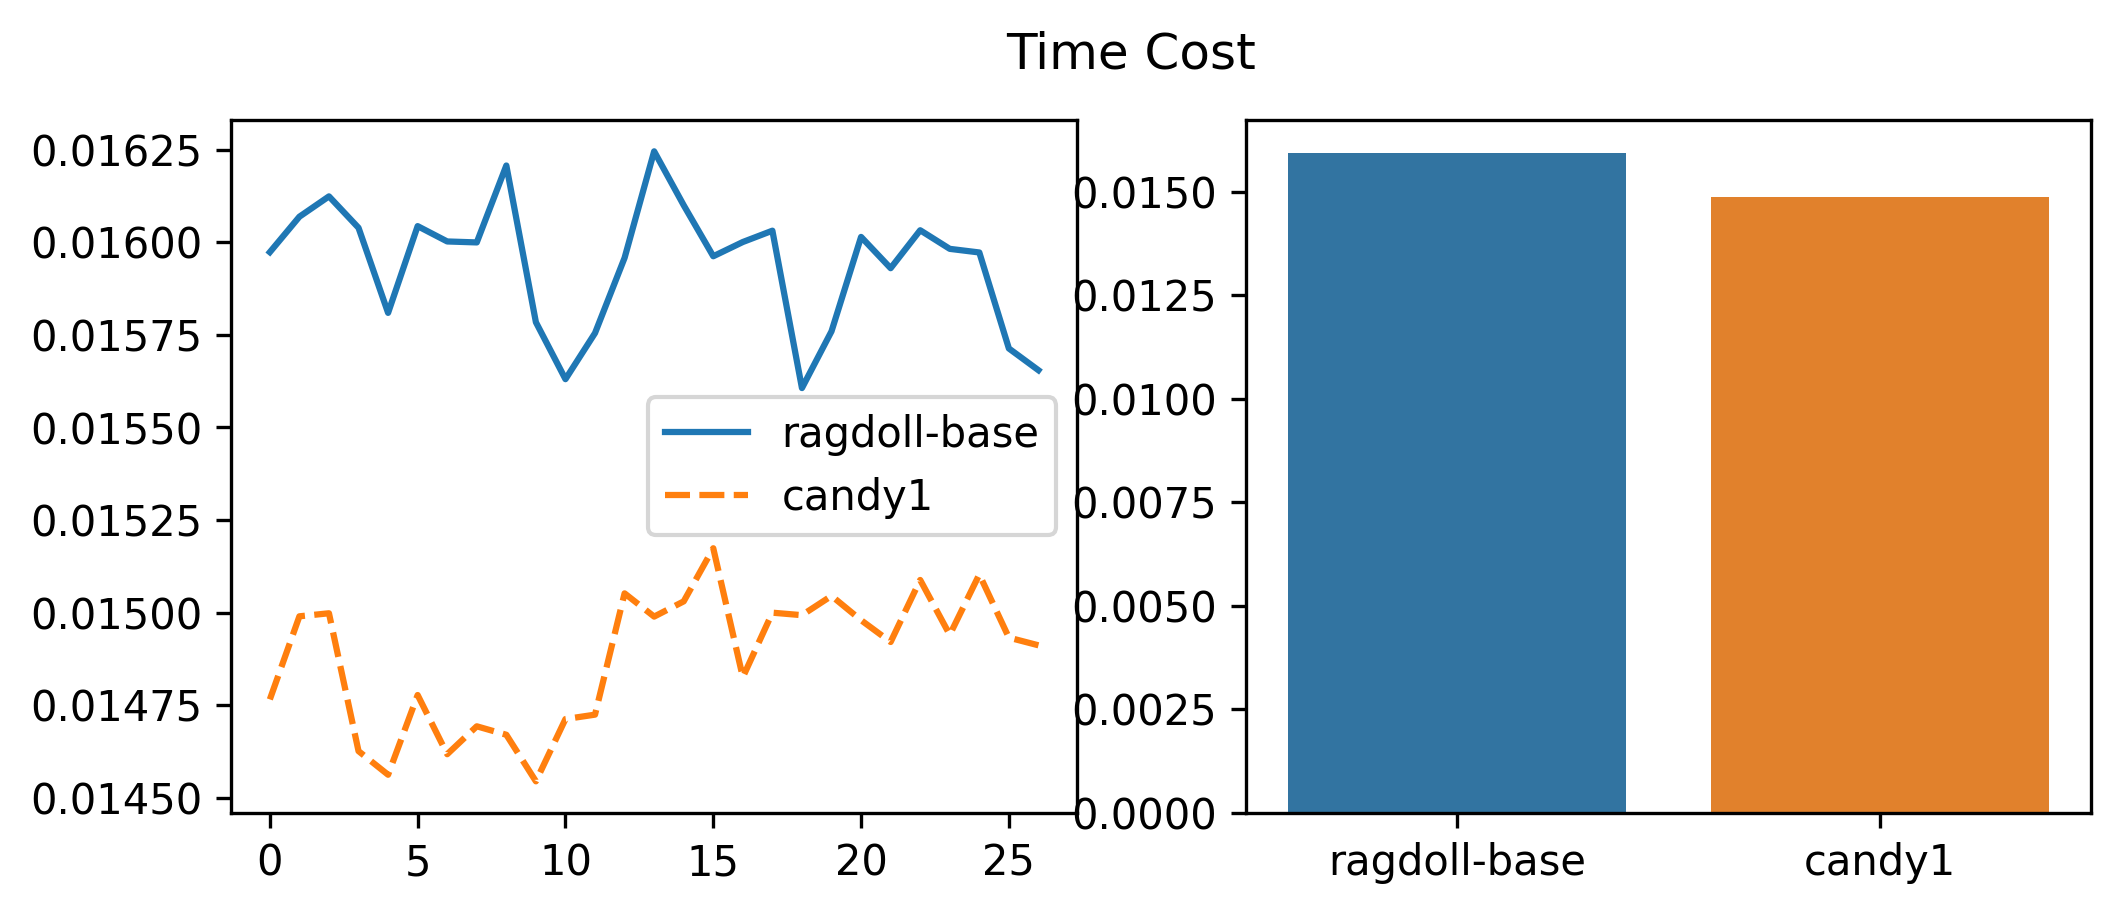

In [13]:
def iree_compile(workload_ir, input_type):
    #binary = iree.compiler.tools.compile_str(
    #    module, input_type="tosa", target_backends=["llvm-cpu"]
    #)
    #binary = iree.compiler.tools.compile_file(
    #    workload_ir, input_type=input_type, target_backends=["cuda"]
    #)
    #CPU
    #config = iree.runtime.system_api.Config("local-task")
    #GPU
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary)
    vmo = iree.runtime.load_vm_module(vmm, config)
    return vmo
def iree_load(workload_fb, input_type):
    #binary = iree.compiler.tools.compile_str(
    #    module, input_type="tosa", target_backends=["llvm-cpu"]
    #)
    #binary = iree.compiler.tools.compile_file(
    #    workload_ir, input_type=input_type, target_backends=["cuda"]
    #)
    #CPU
    #config = iree.runtime.system_api.Config("local-task")
    #GPU
    config = iree.runtime.system_api.Config("cuda")
    vmi = iree.runtime.VmInstance()
    with open(workload_fb, 'rb') as file:
      binary_data = file.read()
    vmm = iree.runtime.VmModule.from_flatbuffer(vmi, binary_data)
    print(vmm)
    vmo = iree.runtime.load_vm_module(vmm, config)
    print(vmo)
    return vmo
base_iree_module = iree_load(workload_fb="../../build/.matmul.vmfb", input_type="tosa")
candy1_iree_module = iree_load(workload_fb="../../build/.matmul.candidate1.vmfb", input_type="auto")

from functools import wraps
from time import perf_counter
from collections import namedtuple

TestResult = namedtuple("TestResult", ("res", "forward_timecost"))


TimerResult = namedtuple("TimerResult", ("result", "timecost"))

def timer(func):
    @wraps(func)
    def wrapper(*args, **kwargs):
        start = perf_counter()
        res = func(*args, **kwargs)
        end = perf_counter()
        \
        return TimerResult(res, end - start)
    return wrapper

def torch_test(lhs, rhs):
    lhs, rhs = [torch.from_numpy(i) for i in [lhs, rhs]]
    lhs.requires_grad = True
    rhs.requires_grad = True
    
    @timer
    def forward():
        return torch.bmm(lhs, rhs)
    
    res, forward_timecost = forward()
    
    return TestResult(res, forward_timecost)
    
def base_iree_test(lhs, rhs):
    @timer
    def forward():
        return base_iree_module["matmul"](lhs, rhs)[0]
    
    res, timecost = forward()
    return TestResult(res, timecost)

def candy1_iree_test(lhs, rhs):
    @timer
    def forward():
        return candy1_iree_module["matmul"](lhs, rhs)[0]
    
    res, timecost = forward()
    return TestResult(res, timecost)

def test_all_ntimes(n):
    lhs_list = [np.random.randn(1026, 2556).astype(np.float32) for _ in range(n)]
    rhs_list = [np.random.randn(2556, 1026).astype(np.float32) for _ in range(n)]
    
    def test(func):
        test_results = []
        for lhs, rhs in zip(lhs_list, rhs_list):
            test_results.append(func(lhs, rhs))
        return test_results
    # use python 310 env templly
    #torch_result = test(torch_test)
    base_iree_result = test(base_iree_test)
    candy1 = test(candy1_iree_test)
    #return torch_result, base_iree_result, candy1
    return base_iree_result, candy1
    
# names = ["torch 2.0.1", "ragdoll-base", "candy1"]
names = ["ragdoll-base", "candy1"]
def get_forward_array(res):
    return np.array(list(map(lambda x : x.forward_timecost, res)))[4:]

results = test_all_ntimes(31)
forward_line = pd.DataFrame(dict(zip(names, [get_forward_array(res) for res in results])))
forward_bar = pd.DataFrame(dict(zip(names, [[np.mean(get_forward_array(res))] for res in results])))

plt.rcParams["figure.dpi"] = 300
plt.rcParams["figure.figsize"] = (3, 3)

fig, (left, right) = plt.subplots(ncols=2, figsize=(8, 3))
sns.lineplot(forward_line, ax=left)
sns.barplot(forward_bar, ax=right)
plt.suptitle("Time Cost")

In [14]:
!../../codegen_tools_install/iree/bin/iree-benchmark-module --help

# ============================================================================
# 👻 IREE: iree-benchmark-module
# ============================================================================

Benchmarks a function within a compiled IREE module and handles I/O
parsing. Modules can be provided by file path (`--module=file.vmfb`)
or read from stdin (`--module=-`) and the function to execute
matches the original name provided to the compiler
(`--function=foo` for `func.func @foo`).

# ===----------------------------------------------------------------------===
# Flags in ragdoll-codegen/runtime/src/iree/base/internal/flags.c
# ===----------------------------------------------------------------------===

# Displays command line usage information.
# --help

# Parses a newline-separated list of flags from a file.
# Flags are parsed at the point where the flagfile is specified
# and following flags may override the parsed values.
# NOTE: this --help output is a flagfile! Pipe this to a file, tw

In [15]:
!../../codegen_tools_install/iree/bin/iree-benchmark-module \
--module=../../build/.matmul.vmfb.benchmark \
--device=cuda \
--function=matmul \
--input=1026x2556xf32 \
--input=2556x1026xf32 \
--batch_size=17 \
--benchmark_min_time=1s \
--print_statistics=true

2024-02-19T17:38:24+08:00
Running ../../codegen_tools_install/iree/bin/iree-benchmark-module
Run on (48 X 3800 MHz CPU s)
CPU Caches:
  L1 Data 32 KiB (x24)
  L1 Instruction 32 KiB (x24)
  L2 Unified 512 KiB (x24)
  L3 Unified 16384 KiB (x8)
Load Average: 0.18, 0.07, 0.08
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
-------------------------------------------------------------------------------------------
Benchmark                                 Time             CPU   Iterations UserCounters...
-------------------------------------------------------------------------------------------
BM_matmul/process_time/real_time       1.74 ms        0.088 ms          833 items_per_second=573.633/s
[[ iree_hal_allocator_t memory statistics ]]
  HOST_LOCAL:            0B peak /            0B allocated /            0B freed /            0B live
DEVICE_LOCAL:    273621888B peak /    252642240B allocated /    252642240B freed /

In [16]:
!../../codegen_tools_install/iree/bin/iree-benchmark-module \
--module=../../build/.matmul.candidate1.vmfb.benchmark \
--device=cuda \
--function=matmul \
--input=1026x2556xf32 \
--input=2556x1026xf32 \
--batch_size=17 \
--benchmark_min_time=1s \
--print_statistics=true

2024-02-19T17:38:26+08:00
Running ../../codegen_tools_install/iree/bin/iree-benchmark-module
Run on (48 X 3800 MHz CPU s)
CPU Caches:
  L1 Data 32 KiB (x24)
  L1 Instruction 32 KiB (x24)
  L2 Unified 512 KiB (x24)
  L3 Unified 16384 KiB (x8)
Load Average: 0.17, 0.07, 0.08
***WARNING*** CPU scaling is enabled, the benchmark real time measurements may be noisy and will incur extra overhead.
-------------------------------------------------------------------------------------------
Benchmark                                 Time             CPU   Iterations UserCounters...
-------------------------------------------------------------------------------------------
BM_matmul/process_time/real_time       1.01 ms        0.062 ms         1394 items_per_second=992.849/s
[[ iree_hal_allocator_t memory statistics ]]
  HOST_LOCAL:            0B peak /            0B allocated /            0B freed /            0B live
DEVICE_LOCAL:    412575120B peak /    391595472B allocated /    391595472B freed /